## **Introducción**

Tenemos como objetivo realizar un análisis financiero exhaustivo de la acción Apple Inc. (AAPL) utilizando datos reales obtenidos a través de la librería yfinance.
Desde un punto de vista empresarial y financiero, Apple representa uno de los activos más relevantes del mercado bursátil global, siendo una compañía líder en innovación, capitalización bursátil y estabilidad financiera.
El análisis desarrollado en este proyecto se centra en:

Estudiar la evolución histórica del precio de Apple
Analizar su comportamiento en términos de riesgo y rentabilidad
Comparar su desempeño con otros activos relevantes del mercado
Construir modelos predictivos a diferentes horizontes temporales
Evaluar la capacidad predictiva y sus limitaciones

Todo el análisis se apoya fuertemente en visualizaciones, con el objetivo de facilitar la interpretación tanto a perfiles técnicos como no técnicos.


Importación de librerias

In [21]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor



Descarga de datos financieros con yfinance

In [22]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2018-01-01",
    end="2025-01-01"
)

data.head()

/tmp/ipykernel_1570/414190857.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297153,40.839972,40.233983,40.367346,118071600
2018-01-04,40.484318,40.587266,40.262044,40.369670,89738400
2018-01-05,40.945255,41.031824,40.489009,40.580258,94640000
2018-01-08,40.793179,41.087983,40.694907,40.793179,82271200


In [23]:
data = data.dropna()
data["Returns"] = data["Close"].pct_change()
data = data.dropna()

data.describe()

Price,Close,High,Low,Open,Volume,Returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
count,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03,1760.000000
mean,121.782719,122.990804,120.438092,121.661306,1.001405e+08,0.001220
std,59.047947,59.516651,58.486561,58.975965,5.522876e+07,0.019242
min,33.768078,34.606402,33.722955,34.193175,2.323470e+07,-0.128647
25%,54.171117,54.793960,53.770464,54.261023,6.303968e+07,-0.008035
50%,131.318977,132.816896,129.963622,131.767774,8.671055e+07,0.001276
75%,168.494930,170.067712,167.066044,168.317502,1.214590e+08,0.011506
max,257.612732,258.686881,256.230300,256.787255,4.265100e+08,0.119808


In [24]:

ticker = "AAPL"

data = yf.download(
    ticker,
    start="2018-01-01",
    end="2025-01-01"
)

data.head()


/tmp/ipykernel_1570/387930462.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297153,40.839972,40.233983,40.367346,118071600
2018-01-04,40.484318,40.587266,40.262044,40.369670,89738400
2018-01-05,40.945255,41.031824,40.489009,40.580258,94640000
2018-01-08,40.793179,41.087983,40.694907,40.793179,82271200


Limpieza y preparación de los datos

In [25]:

data = data.dropna()
data["Returns"] = data["Close"].pct_change()
data = data.dropna()

data.describe()

Price,Close,High,Low,Open,Volume,Returns
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
count,1760.000000,1760.000000,1760.000000,1760.000000,1.760000e+03,1760.000000
mean,121.782719,122.990804,120.438092,121.661306,1.001405e+08,0.001220
std,59.047947,59.516651,58.486561,58.975965,5.522876e+07,0.019242
min,33.768078,34.606402,33.722955,34.193175,2.323470e+07,-0.128647
25%,54.171117,54.793960,53.770464,54.261023,6.303968e+07,-0.008035
50%,131.318977,132.816896,129.963622,131.767774,8.671055e+07,0.001276
75%,168.494930,170.067712,167.066044,168.317502,1.214590e+08,0.011506
max,257.612732,258.686881,256.230300,256.787255,4.265100e+08,0.119808


##**Visualización de la evolución del precio de Apple**

Precio de cierre(escala lineal)

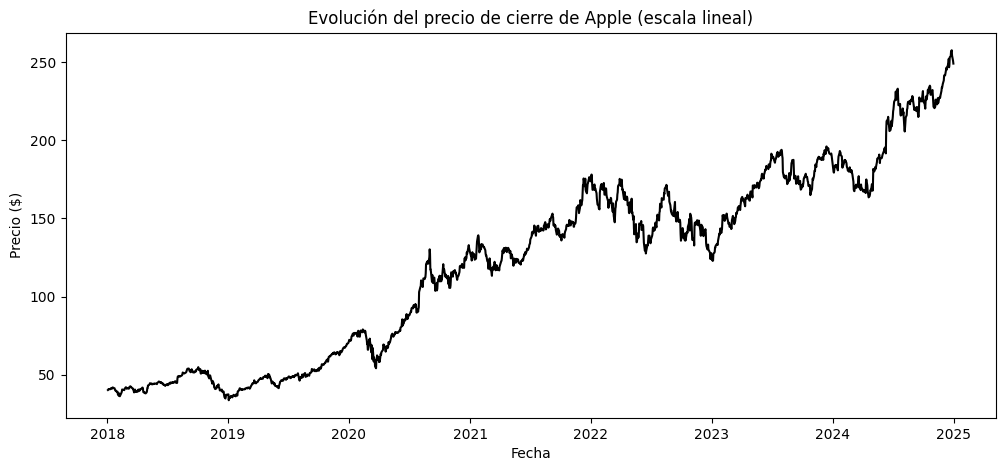

In [26]:

plt.figure(figsize=(12,5))
plt.plot(data.index, data["Close"], color="black")
plt.title("Evolución del precio de cierre de Apple (escala lineal)")
plt.xlabel("Fecha")
plt.ylabel("Precio ($)")
plt.show()



Precio de cierre (escala logarítmica)

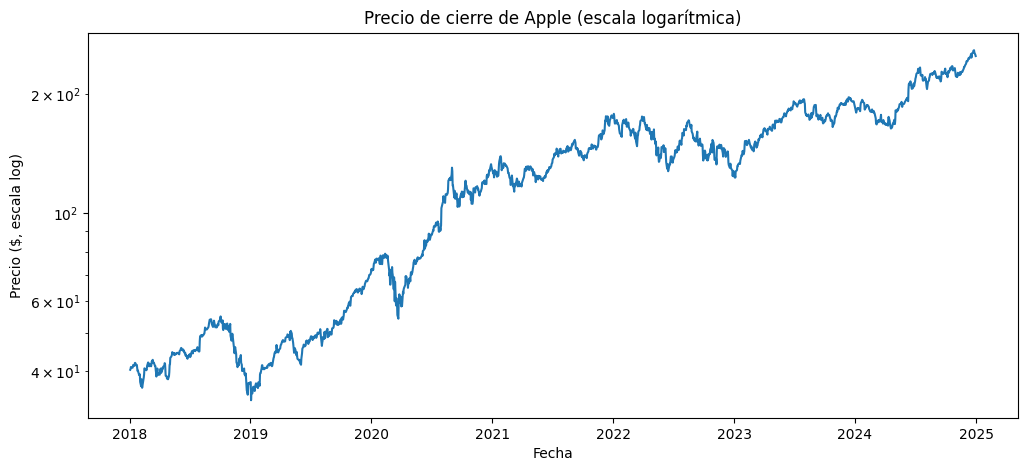

In [27]:


plt.figure(figsize=(12,5))
plt.plot(data.index, data["Close"])
plt.yscale("log")
plt.title("Precio de cierre de Apple (escala logarítmica)")
plt.xlabel("Fecha")
plt.ylabel("Precio ($, escala log)")
plt.show()



Volumen de negociación

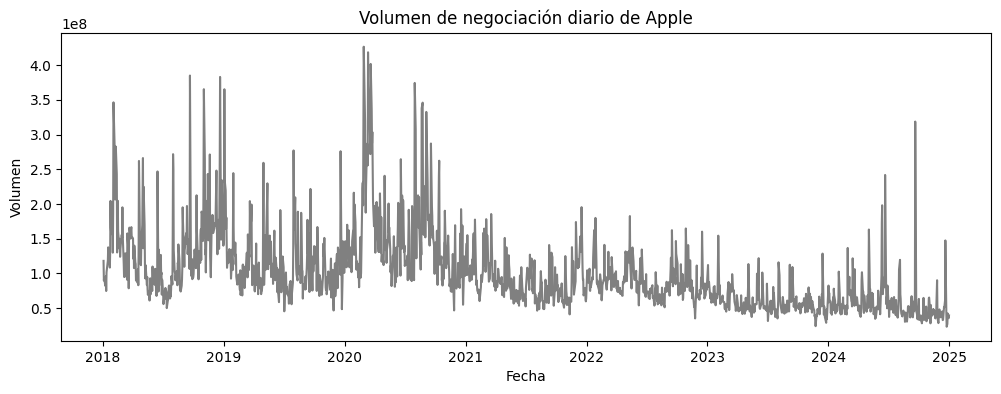

In [28]:


plt.figure(figsize=(12,4))
plt.plot(data.index, data["Volume"], color="gray")
plt.title("Volumen de negociación diario de Apple")
plt.xlabel("Fecha")
plt.ylabel("Volumen")
plt.show()


Precio y volumen combinados

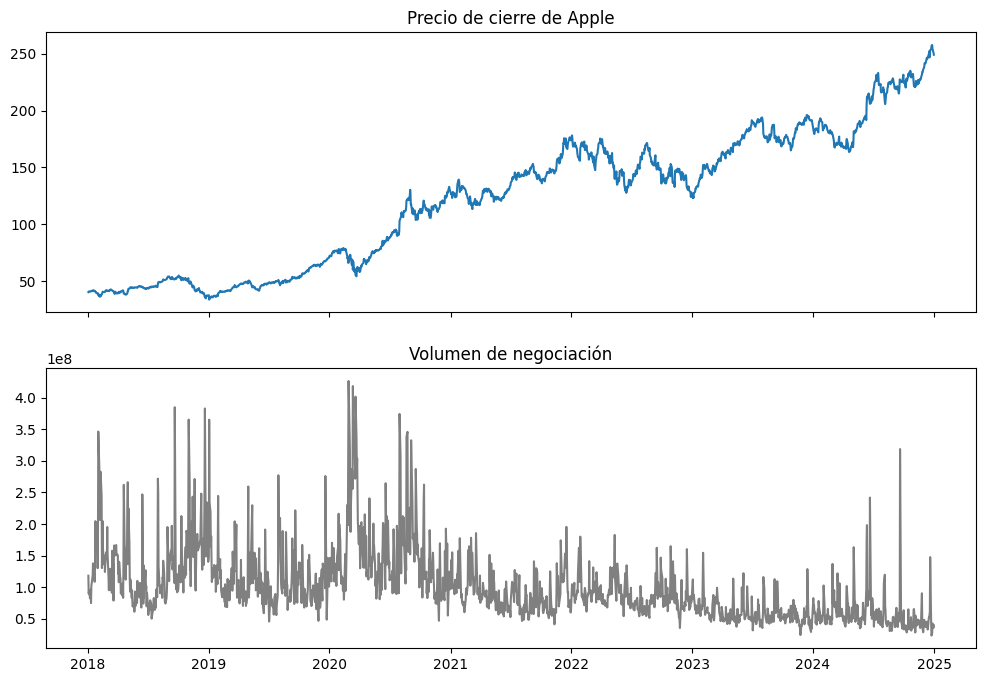

In [29]:


fig, ax = plt.subplots(2, 1, figsize=(12,8), sharex=True)

ax[0].plot(data.index, data["Close"])
ax[0].set_title("Precio de cierre de Apple")

ax[1].plot(data.index, data["Volume"], color="gray")
ax[1].set_title("Volumen de negociación")

plt.show()


Medias móviles y análisis de tendencia

In [30]:

data["MA20"] = data["Close"].rolling(20).mean()
data["MA50"] = data["Close"].rolling(50).mean()
data["MA100"] = data["Close"].rolling(100).mean()


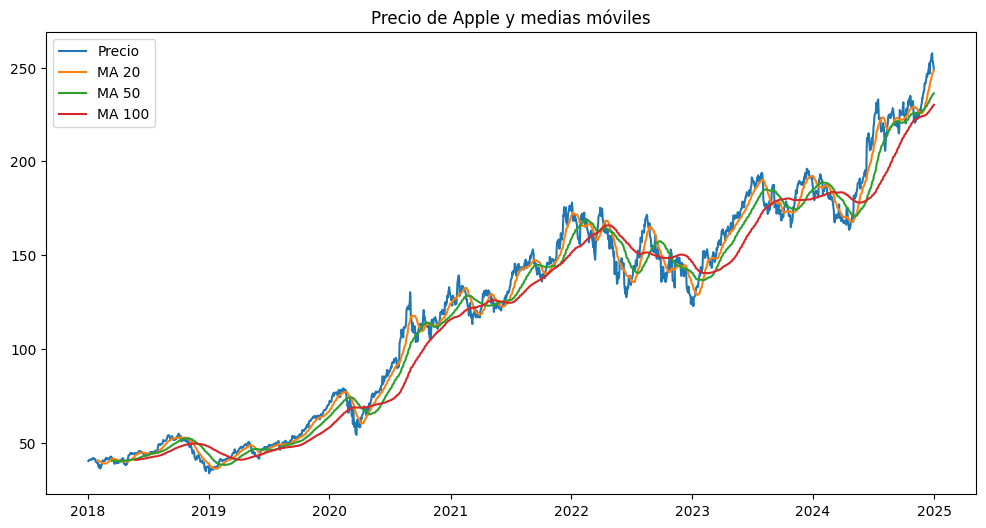

In [31]:

plt.figure(figsize=(12,6))
plt.plot(data["Close"], label="Precio")
plt.plot(data["MA20"], label="MA 20")
plt.plot(data["MA50"], label="MA 50")
plt.plot(data["MA100"], label="MA 100")
plt.legend()
plt.title("Precio de Apple y medias móviles")
plt.show()



Comparación con otros activos del mercado

In [32]:

tickers = ["AAPL", "MSFT", "SPY"]

comparison = yf.download(
    tickers,
    start="2018-01-01",
    end="2025-01-01"
)["Close"]

comparison = comparison.dropna()


/tmp/ipykernel_1570/922684783.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  comparison = yf.download(
[*********************100%***********************]  3 of 3 completed


Precios normalizados

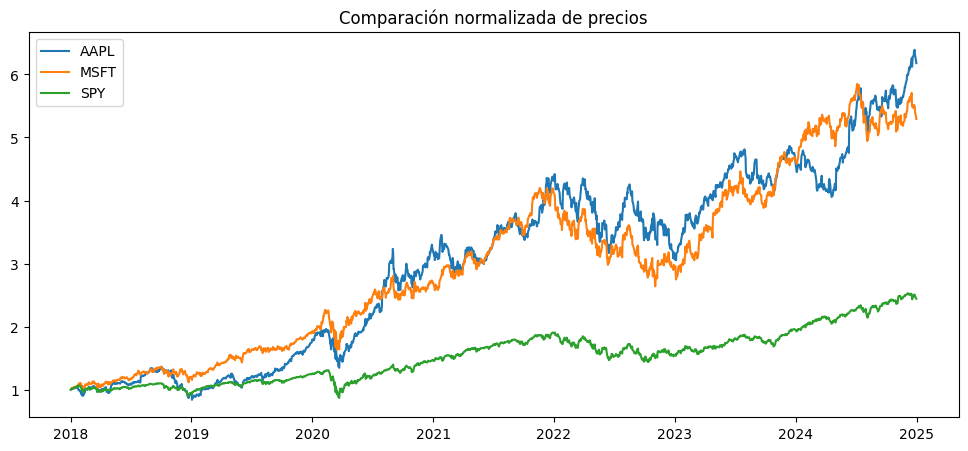

In [33]:

comparison_norm = comparison / comparison.iloc[0]

plt.figure(figsize=(12,5))
for col in comparison_norm.columns:
    plt.plot(comparison_norm[col], label=col)

plt.title("Comparación normalizada de precios")
plt.legend()
plt.show()


 Rendimientos acumulados comparados

In [34]:

returns_comp = comparison.pct_change().dropna()
cum_returns_comp = (1 + returns_comp).cumprod()


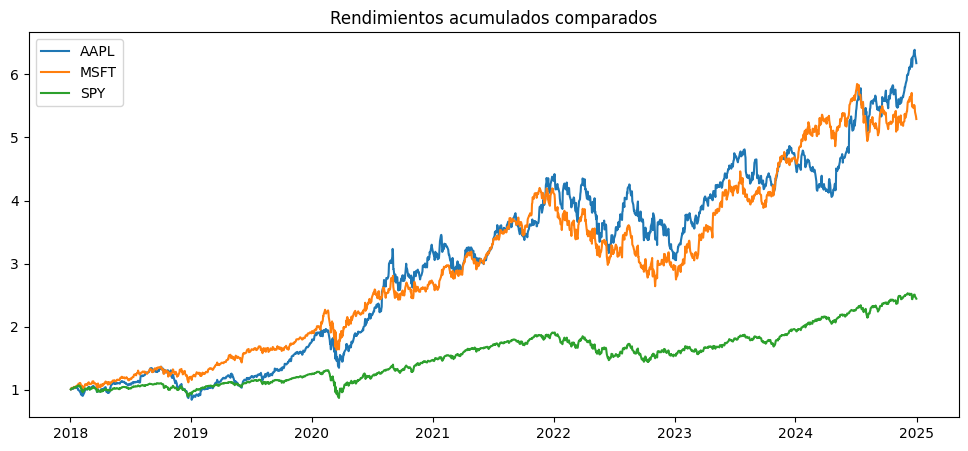

In [35]:

plt.figure(figsize=(12,5))
for col in cum_returns_comp.columns:
    plt.plot(cum_returns_comp[col], label=col)

plt.title("Rendimientos acumulados comparados")
plt.legend()
plt.show()


Heatmap de correlación

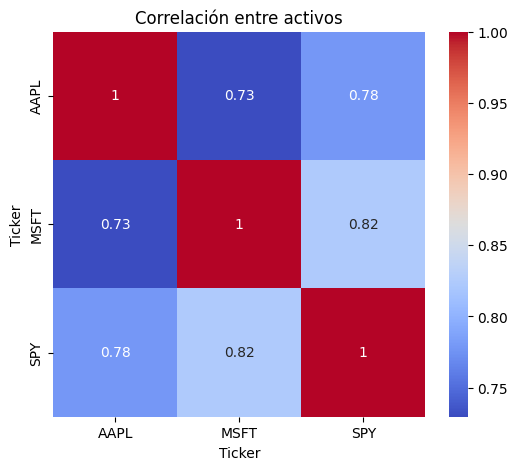

In [36]:

plt.figure(figsize=(6,5))
sns.heatmap(returns_comp.corr(), annot=True, cmap="coolwarm")
plt.title("Correlación entre activos")
plt.show()


Preparación del dataset para predicción

In [44]:
def create_lagged_features(df, lags=10):
    lagged = pd.DataFrame()
    for i in range(1, lags + 1):
        lagged[f"lag_{i}"] = df["Close"].shift(i)
    lagged["target"] = df["Close"]
    return lagged.dropna()

In [45]:

dataset = create_lagged_features(data, lags=10)
X = dataset.drop("target", axis=1)
y = dataset["target"]



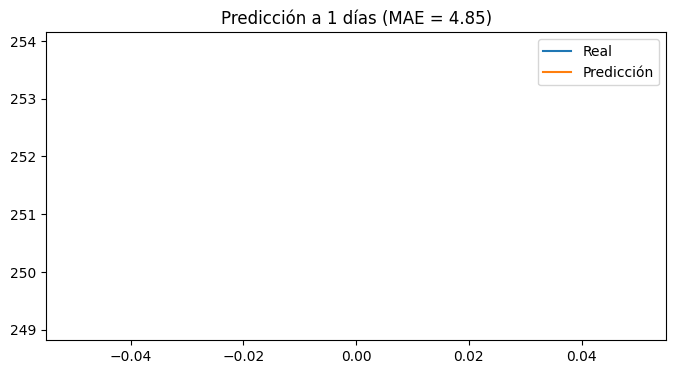

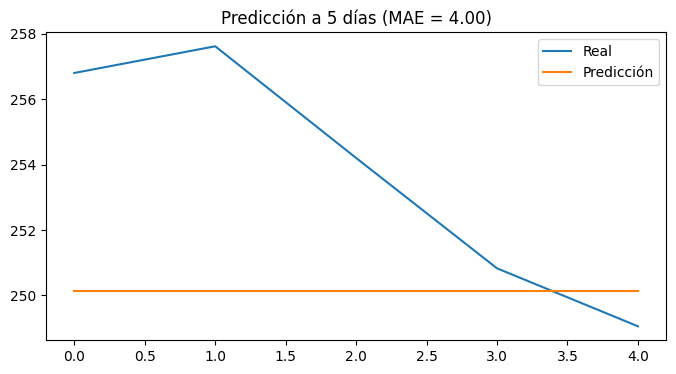

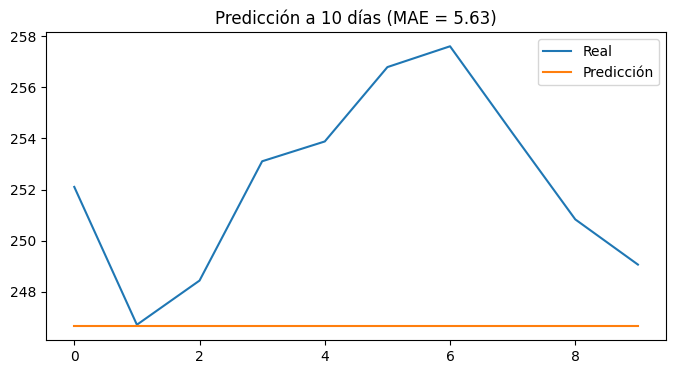

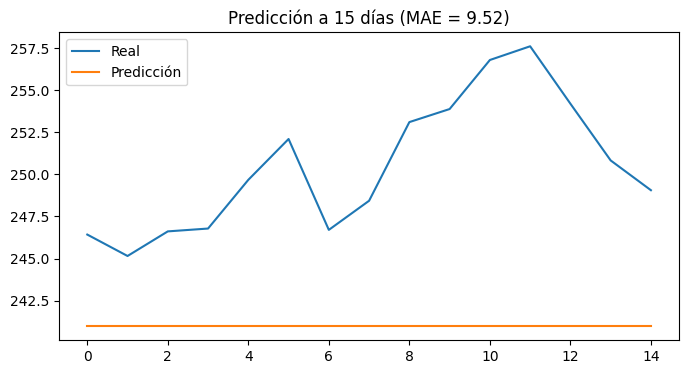

In [56]:
horizons = [1, 5, 10, 15]
mae_results = {}

for h in horizons:
    preds, real, mae = train_and_predict(X, y, h)
    mae_results[h] = mae

    plt.figure(figsize=(8,4))
    plt.plot(real.values, label="Real")
    plt.plot(preds, label="Predicción")
    plt.title(f"Predicción a {h} días (MAE = {mae:.2f})")
    plt.legend()
    plt.show()

In [47]:

dataset = create_lagged_features(data, lags=10)
X = dataset.drop("target", axis=1)
y = dataset["target"]


Modelo predictivo (XGBoost)

In [50]:

def train_and_predict(X, y, horizon):
    X_train, X_test = X[:-horizon], X[-horizon:]
    y_train, y_test = y[:-horizon], y[-horizon:]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    return preds, y_test, mae


Evolución del MAE por horizonte

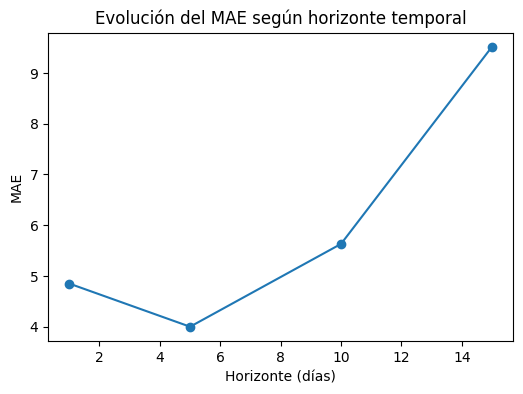

In [85]:

plt.figure(figsize=(6,4))
plt.plot(list(mae_results.keys()), list(mae_results.values()), marker="o")
plt.title("Evolución del MAE según horizonte temporal")
plt.xlabel("Horizonte (días)")
plt.ylabel("MAE")
plt.show()


##**Predicción del precio de Apple a 1, 5, 10 y 15 días**



In [87]:

model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

model.fit(X, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Función para predecir precios futuros (forecast real)

In [88]:

def forecast_prices(model, last_prices, n_days):
    predictions = []
    current_input = last_prices.copy()

    for _ in range(n_days):
        pred = model.predict(current_input.values.reshape(1, -1))[0]
        predictions.append(pred)

        # Actualizamos el vector de entrada
        current_input = current_input.shift(-1)
        current_input.iloc[-1] = pred

    return predictions


In [89]:
last_prices = X.iloc[-1]

In [90]:

horizons = [1, 5, 10, 15]
forecast_results = {}

for h in horizons:
    forecast_results[h] = forecast_prices(model, last_prices, h)


In [91]:

for h in horizons:
    print(f"\nPredicción de Apple a {h} día(s):")
    for i, price in enumerate(forecast_results[h], 1):
        print(f"Día {i}: {price:.2f} $")



Predicción de Apple a 1 día(s):
Día 1: 253.38 $

Predicción de Apple a 5 día(s):
Día 1: 253.38 $
Día 2: 253.38 $
Día 3: 253.38 $
Día 4: 253.38 $
Día 5: 253.38 $

Predicción de Apple a 10 día(s):
Día 1: 253.38 $
Día 2: 253.38 $
Día 3: 253.38 $
Día 4: 253.38 $
Día 5: 253.38 $
Día 6: 253.58 $
Día 7: 252.33 $
Día 8: 252.28 $
Día 9: 253.38 $
Día 10: 253.38 $

Predicción de Apple a 15 día(s):
Día 1: 253.38 $
Día 2: 253.38 $
Día 3: 253.38 $
Día 4: 253.38 $
Día 5: 253.38 $
Día 6: 253.58 $
Día 7: 252.33 $
Día 8: 252.28 $
Día 9: 253.38 $
Día 10: 253.38 $
Día 11: 253.38 $
Día 12: 253.38 $
Día 13: 253.38 $
Día 14: 253.38 $
Día 15: 253.38 $


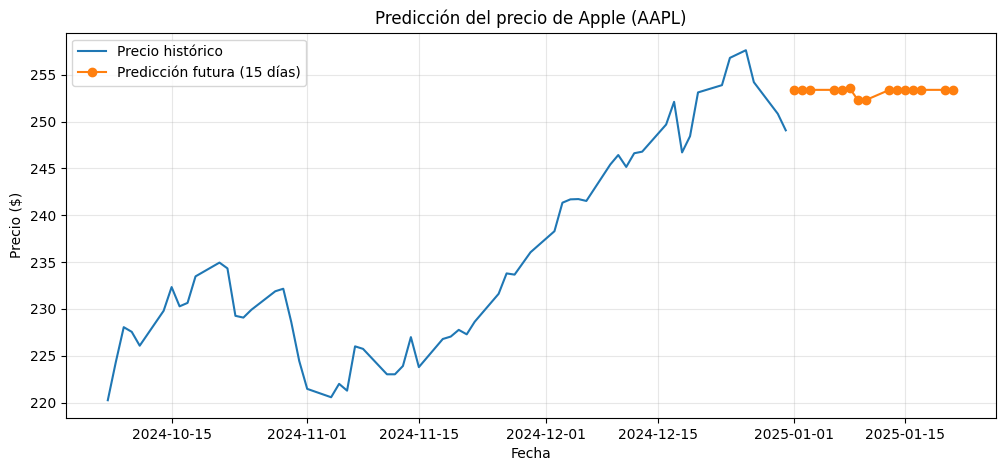

In [92]:

plt.figure(figsize=(12,5))

# Histórico (últimos 60 días)
plt.plot(
    data.index[-60:],
    data["Close"].iloc[-60:],
    label="Precio histórico"
)

# Predicción futura (15 días)
future_prices = forecast_results[15]
future_dates = pd.date_range(
    start=data.index[-1],
    periods=16,
    freq="B"
)[1:]

plt.plot(
    future_dates,
    future_prices,
    label="Predicción futura (15 días)",
    marker="o"
)

plt.title("Predicción del precio de Apple (AAPL)")
plt.xlabel("Fecha")
plt.ylabel("Precio ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


5 dias

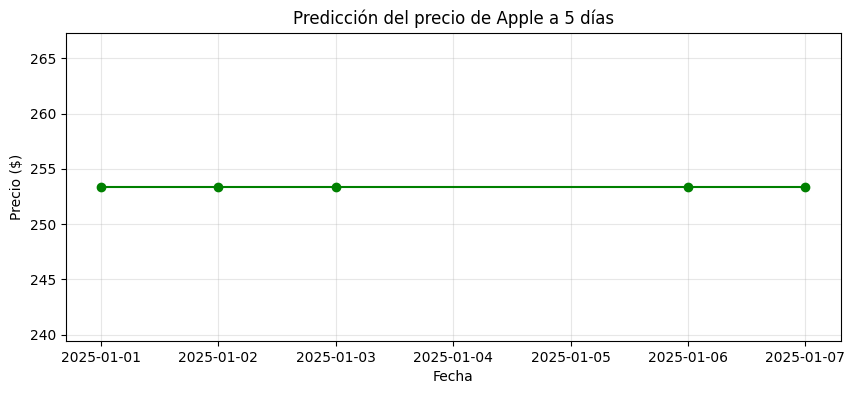

In [93]:

plt.figure(figsize=(10,4))

future_dates_5 = pd.date_range(
    start=data.index[-1],
    periods=6,
    freq="B"
)[1:]

plt.plot(
    future_dates_5,
    forecast_results[5],
    marker="o",
    color="green"
)

plt.title("Predicción del precio de Apple a 5 días")
plt.xlabel("Fecha")
plt.ylabel("Precio ($)")
plt.grid(alpha=0.3)
plt.show()


10 dias

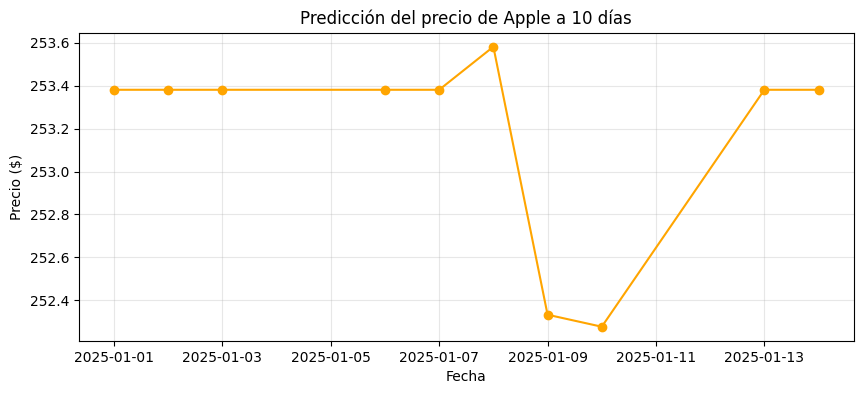

In [96]:

plt.figure(figsize=(10,4))

future_dates_10 = pd.date_range(
    start=data.index[-1],
    periods=11,
    freq="B"
)[1:]

plt.plot(
    future_dates_10,
    forecast_results[10],
    marker="o",
    color="orange"
)

plt.title("Predicción del precio de Apple a 10 días")
plt.xlabel("Fecha")
plt.ylabel("Precio ($)")
plt.grid(alpha=0.3)
plt.show()


15 dias

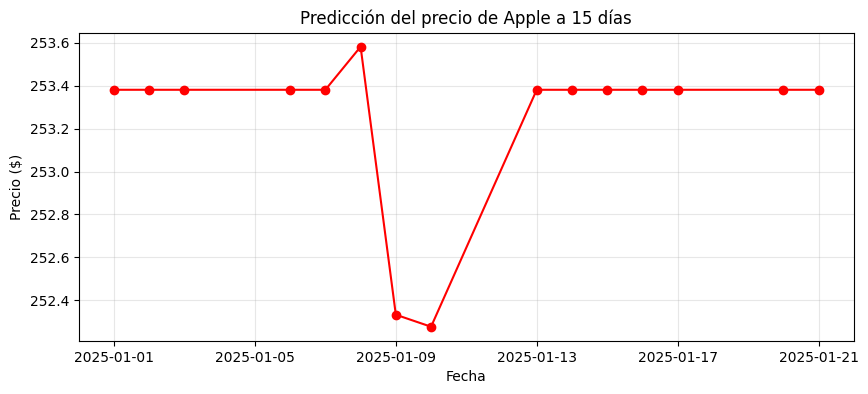

In [99]:

plt.figure(figsize=(10,4))

# Define future_dates_15
future_dates_15 = pd.date_range(
    start=data.index[-1],
    periods=16,
    freq="B"
)[1:]

plt.plot(
    future_dates_15,
    forecast_results[15],
    marker="o",
    color="red"
)

plt.title("Predicción del precio de Apple a 15 días")
plt.xlabel("Fecha")
plt.ylabel("Precio ($)")
plt.grid(alpha=0.3)
plt.show()
